# <font color=#0099CC>**ANÁLISIS DE ARBITRAJE DE ALTA FRECUENCIA EN MERCADOS FRAGMENTADOS**</font>

### **Fecha: 09/12/2025 | Autor: Javier Fernández Guerra**

## <font color=#0099CC>**0. INTRODUCCIÓN**</font>
Este jupiter notebook analiza oportunidades de arbitraje en acciones españolas a través de múltiples plataformas de negociación (BME, CBOE, Turquoise, Aquis). Vamos a:

1. Cargar y limpiar los datos del mercado (cotizaciones QTE y estado de negociación STS)
2. Construir una cinta consolidada para comparar precios entre plataformas en los mismos timestamps
3. Detectar señales de arbitraje cuando `Max Bid > Min Ask` entre plataformas
4. Simular la degradación por latencia para entender cómo se erosiona la ganancia con los retrasos en la ejecución
5. Validar los resultados y hacer una simulación alternativa utilizando órdenes limitadas

En este proyecto se establecen una serie de supuestos clave:

- Solo se negocia durante las fases de Negociación Continua (usando códigos de estado específicos del proveedor)
- Se filtran números mágicos (códigos de precio especiales que indican estados no negociables)
- Se usa solo la mejor compra/venta (nivel 0) por simplicidad
- Se pone en marcha un enfoque de rising edge que previene contar dos veces oportunidades persistentes

In [1]:
# Librerías
import os
from pathlib import Path
from functools import reduce

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from datetime import datetime, timezone

In [2]:
# Estilo
plt.style.use('dark_background')

In [3]:
# Base de datos a analizar: "DATA_SMALL" o "DATA_BIG"
root_dir = "DATA_BIG"  # recomendada

> <u>IMPORTANTE</u>: Si se quiere explorar `DATA_SMALL` en lugar de `DATA_BIG` se debe especificar en este punto del notebook cambiando el valor de `root_dir`.

## <font color=#0099CC>**1. CARGA DE LOS DATOS**</font>

Esta sección se encarga de la carga de archivos de datos de mercado en crudo:

- **Archivos QTE**: Contienen instantáneas del libro de órdenes (precios y cantidades en cada nivel)
- **Archivos STS**: Contienen actualizaciones del estado de negociación (información sobre la fase del mercado)

El código encuentra todos los archivos `.csv.gz` de manera recursiva, los clasifica por tipo y los agrupa por **identidad del libro de órdenes**: `(sesión, isin, mic, ticker)`.


In [4]:
# Descubrimiento de archivos en cualquier profundidad
def discover_files(root_dir):
    """
    Devuelve todos los archivos .csv.gz dentro de root_dir
    y subcarpetas, sin asumir estructura.
    """
    root = Path(root_dir)
    return list(root.rglob("*.csv.gz"))


# Separación por tipo: QTE / STS según filename
def classify_files(filepaths):
    """
    Recibe todos los .csv.gz encontrados y los separa en QTE y STS
    según el prefijo del archivo, sin depender de estructura ni carpetas.
    """
    qte_files = []
    sts_files = []

    for fp in filepaths:
        name = fp.name.upper()

        if name.startswith("QTE_"):
            qte_files.append(fp)
        elif name.startswith("STS_"):
            sts_files.append(fp)

    return qte_files, sts_files


# Extraer metadatos del nombre de archivo (ISIN, MIC, TICKER, SESSION)
def extract_metadata(filepath):
    """
    Extrae metadatos del nombre del archivo según pattern:
    <type>_<session>_<isin>_<ticker>_<mic>_<part>.csv.gz
    """
    name = filepath.name.replace(".csv.gz", "")
    parts = name.split("_")

    return {
        "type":   parts[0] if len(parts) > 0 else None,
        "session": parts[1] if len(parts) > 1 else None,
        "isin":    parts[2] if len(parts) > 2 else None,
        "ticker":  parts[3] if len(parts) > 3 else None,
        "mic":     parts[4] if len(parts) > 4 else None,
        "part":    parts[5] if len(parts) > 5 else None,
    }


# Carga genérica de archivos QTE/STS sin limpieza
def load_generic_csv_gz(filepath):
    """
    Carga un .csv.gz con pandas usando compresión automática.
    """
    try:
        return pd.read_csv(filepath, compression="gzip", sep=';')
    except Exception as e:
        print(f"[ERROR] {filepath}: {e}")
        return pd.DataFrame()


# Agrupación por orderbook (session, isin, mic, ticker)
def build_orderbooks(qte_files, sts_files):
    """
    Devuelve un diccionario:
    {
        (session, isin, mic, ticker): {
            "qte": DataFrame,
            "sts": DataFrame
        }
    }
    """
    orderbooks = {}

    # --- Procesar QTE ---
    for fp in qte_files:
        meta = extract_metadata(fp)
        key = (meta["session"], meta["isin"], meta["mic"], meta["ticker"])

        df = load_generic_csv_gz(fp)
        if df.empty:
            continue

        if key not in orderbooks:
            orderbooks[key] = {"qte": None, "sts": None}

        if orderbooks[key]["qte"] is None:
            orderbooks[key]["qte"] = df
        else:
            orderbooks[key]["qte"] = pd.concat([orderbooks[key]["qte"], df], ignore_index=True)

    # --- Procesar STS ---
    for fp in sts_files:
        meta = extract_metadata(fp)
        key = (meta["session"], meta["isin"], meta["mic"], meta["ticker"])

        df = load_generic_csv_gz(fp)
        if df.empty:
            continue

        if key not in orderbooks:
            orderbooks[key] = {"qte": None, "sts": None}

        if orderbooks[key]["sts"] is None:
            orderbooks[key]["sts"] = df
        else:
            orderbooks[key]["sts"] = pd.concat([orderbooks[key]["sts"], df], ignore_index=True)

    return orderbooks


# Carga completa del dataset (sin limpieza)
def load_full_dataset(root_dir):
    """
    Carga todo el dataset:
    - Descubre archivos en cualquier nivel
    - Separa QTE / STS
    - Agrupa por orderbook (session, isin, mic, ticker)
    """
    all_files = discover_files(root_dir)
    qte_files, sts_files = classify_files(all_files)

    print(f"Encontrados: {len(qte_files)} QTE, {len(sts_files)} STS")

    orderbooks = build_orderbooks(qte_files, sts_files)

    print(f"Orderbooks construidos: {len(orderbooks)}")
    return orderbooks


## <font color=#0099CC>**2. ANÁLISIS EXPLORATORIO DE LOS DATOS**</font>

Antes de procesar, exploramos el conjunto de datos para entender:

- **Qué MICs (Códigos de Identificación de Mercado)** están presentes en los datos
- **Distribución de los códigos de estado de negociación** por plataforma

Esto es crucial porque la especificación del ejercicio solo mencionaba algunos MICs, pero los datos reales pueden contener adicionales (MABX, GROW, XLAT) que deben ser mapeados correctamente.


### <font color=#336699>**2.1. FUNCIONES EDA**</font>

In [5]:
# Descubrir todos los MIC que aparecen en los QTE
def discover_mics(orderbooks_raw):
    mics = set()

    for key, data in orderbooks_raw.items():
        qte = data.get("qte", None)
        if qte is not None and not qte.empty and "mic" in qte.columns:
            mics.update(qte["mic"].unique())

    return sorted(mics)

# Descubrir qué MIC aparecen en cada STS
def discover_mics_sts(orderbooks_raw):
    mics = set()

    for key, data in orderbooks_raw.items():
        sts = data.get("sts", None)
        if sts is not None and not sts.empty and "mic" in sts.columns:
            mics.update(sts["mic"].unique())

    return sorted(mics)


# Ver distribución de market_trading_status por MIC
def market_status_stats(orderbooks_raw):
    stats = {}

    for key, data in orderbooks_raw.items():
        session, isin, mic, ticker = key
        sts = data["sts"]

        if sts.empty:
            continue

        statuses = sts["market_trading_status"].value_counts().to_dict()
        if mic not in stats:
            stats[mic] = {}

        for code, count in statuses.items():
            stats[mic][code] = stats[mic].get(code, 0) + count

    return stats

### <font color=#336699>**2.2. ANÁLISIS EXPLORATORIO DE LOS DATOS (EDA)**</font>

In [6]:
# Cargar el dataset crudo
orderbooks_raw = load_full_dataset(root_dir)

# Descubrir todos los MIC que aparecen en los QTE
mics_qte = discover_mics(orderbooks_raw)
print("MICs encontrados en QTE:", mics_qte)

# Descubrir todos los MIC que aparecen en los STS
mics_sts = discover_mics_sts(orderbooks_raw)
print("MICs encontrados en STS:", mics_sts)


Encontrados: 444 QTE, 449 STS
Orderbooks construidos: 449
MICs encontrados en QTE: ['AQEU', 'CEUX', 'GROW', 'MABX', 'TQEX', 'XLAT', 'XMAD']
MICs encontrados en STS: ['AQEU', 'CEUX', 'GROW', 'MABX', 'TQEX', 'XLAT', 'XMAD']


### <font color=#336699>**2.3. COMENTARIO DE LOS RESULTADOS EDA**</font>

#### 2.3.1. Comentario DATA_SMALL

El análisis exploratorio muestra un conjunto reducido pero consistente: 4 mensajes QTE y 4 STS, a partir de los cuales se construyeron 4 orderbooks. Los MICs presentes en ambos tipos de mensajes son AQEU, CEUX, TQEX y XMAD, lo que indica una correspondencia completa entre QTE y STS y una presencia uniforme de plataformas en los datos.

#### 2.3.1. Comentario DATA_BIG

Los resultados del análisis exploratorio muestran que el conjunto de datos contiene 444 documentos QTE y 449 documentos STS, a partir de los cuales se pudieron construir 449 *orderbooks*, lo que indica una correspondencia prácticamente completa entre ambos tipos de *files*.

Además, se identificó la presencia de siete MICs distintos tanto en QTE como en STS: AQEU, CEUX, GROW, MABX, TQEX, XLAT y XMAD. Esto confirma que, además de los MICs mencionados inicialmente en la especificación, los datos incluyen otros mercados como MABX, GROW y XLAT, que deben ser considerados y mapeados correctamente durante el procesamiento. La consistencia entre los MICs presentes en QTE y STS también sugiere una estructura uniforme del dataset en cuanto a plataformas de negociación representadas.


## <font color=#0099CC>**3. LIMPIEZA DE DATOS**</font>


### <font color=#336699>**3.1. FUNCIONES DE LIMPIEZA DE LOS DATOS**</font>

In [7]:
def clean_qte(df: pd.DataFrame) -> pd.DataFrame:
    """
    Limpieza robusta del DataFrame QTE:
      - descarta magic numbers en px_bid_0 / px_ask_0
      - convierte 0/negativos a NaN (no eliminar filas enteras si hay algo útil)
      - asegura tipos numéricos en columnas relevantes
      - elimina filas donde *ambos* (bid y ask) son NaN (no hay info)
    Devuelve copia (no modifica in-place).
    """
    if df is None or df.empty:
        return pd.DataFrame()

    df = df.copy()

    # Asegurar columnas esperadas existan antes de operar
    expected = ["epoch", "px_bid_0", "px_ask_0", "qty_bid_0", "qty_ask_0"]
    for col in expected:
        if col not in df.columns:
            df[col] = np.nan

    # Forzar tipos numéricos (convierte strings, comas, etc.)
    for col in ["epoch", "px_bid_0", "px_ask_0", "qty_bid_0", "qty_ask_0"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Eliminar MAGIC NUMBERS estrictamente (estos valores no son precios reales)
    MAGIC_NUMBERS = [
        666666.666, 999999.999, 999999.989, 999999.988,
        999999.979, 999999.123
    ]
    for m in MAGIC_NUMBERS:
        df = df[(df["px_bid_0"] != m) & (df["px_ask_0"] != m)]

    # Convertir 0 o negativos a NaN (no asumimos que 0 es válido)
    df.loc[df["px_bid_0"] <= 0, "px_bid_0"] = np.nan
    df.loc[df["px_ask_0"] <= 0, "px_ask_0"] = np.nan
    df.loc[df["qty_bid_0"] <= 0, "qty_bid_0"] = np.nan
    df.loc[df["qty_ask_0"] <= 0, "qty_ask_0"] = np.nan

    # Asegurar orden por epoch ascendente y tipo entero si es posible
    df = df.sort_values("epoch")
    # epoch puede venir como float; lo dejamos numeric (int64 si no hay NaN)
    df["epoch"] = pd.to_numeric(df["epoch"], errors="coerce").astype("Int64")

    # Si tanto bid como ask son NaN, la snapshot no aporta precios -> eliminar
    df = df[~(df["px_bid_0"].isna() & df["px_ask_0"].isna())].reset_index(drop=True)

    return df


### <font color=#336699>**3.2. EXPLICACIÓN DEL PROCESO DE LIMPIEZA DE LOS DATOS**</font>

Se han llevado a cabo los siguientes pasos para la limpieza de los datos: 
-  **Eliminar números mágicos** - No son precios negociables reales, indican órdenes que no pueden ejecutarse de inmediato:
    - `666666.666` → No cotizado/Desconocido
    - `999999.999` → Orden de mercado (al mejor precio)
    - `999999.989` → Orden a la apertura
    - `999999.988` → Orden al cierre
    - `999999.979` → Orden referenciada (Pegged)
    - `999999.123` → No cotizado/Desconocido
-  **Convertir ceros/valores negativos a NaN** - Valores de precio/cantidad inválidos
-  **Ordenar por timestamp** - Asegurar el orden cronológico
-  **Eliminar filas vacías** - Quitar instantáneas sin información de precio útil


## <font color=#0099CC>**4. CONSTRUCCIÓN DE LA CINTA CONSOLIDADA**</font>

### <font color=#336699>**4.1. OBJETIVO DEL APARTADO**</font>
Para detectar arbitraje entre plataformas, necesitamos comparar los precios **en el mismo timestamp** a través de todas las plataformas. La cinta consolidada es un único DataFrame donde:

- **Índice**: Timestamps unificados en epoch (microsegundos)
- **Columnas**: Mejores precios de compra/venta y cantidades para cada plataforma (por ejemplo, `XMAD_bid`, `CEUX_ask`)

### <font color=#336699>**4.2. FILTRADO DE NEGOCIACIÓN**</font>
Solo incluimos instantáneas donde el mercado está en modo de **Negociación Continua**. Cada plataforma tiene códigos de estado específicos que indican esta fase.


In [8]:
# Códigos de Continuous Trading por venue
CONTINUOUS_STATUS = {
    "AQUIS": {5308427},              # AQEU
    "BME": {5832713, 5832756},       # XMAD, MABX, GROW, XLAT (heredados)
    "CBOE": {12255233},              # CEUX
    "TURQUOISE": {7608181},          # TQEX
}

### <font color=#336699>**4.3. MAPEAO MIC - VENUE**</font>
Realizamos el mapeo de cada MIC con su venue principal. Aunque el enunciado solo mencionaba los venues AQUIS, BME, CBOE y TURQUOISE, el análisis exploratorio mostró que en los datos aparecían MICs adicionales.

Estos MICs adicionales no corresponden a nuevos venues, sino a segmentos de mercado (Segment MICs) dentro de los venues ya definidos. Por ejemplo, MABX, GROW y XLAT son segmentos operados por BME, mientras que CEUX y TQEX pertenecen a CBOE y TURQUOISE, respectivamente.

Este mapeo garantiza que todos los segmentos identificados en los datos queden correctamente asociados a su venue principal.

In [9]:
# Mapeo MIC → Venue
MIC_TO_VENUE = {
    "AQEU": "AQUIS",       # AQUIS Exchange Europe (MLTF: París, Francia)
    "XMAD": "BME",         # Bolsa de Madrid (RMKT: Madrid, España)
    "MABX": "BME",         # Mercado Alternativo Bursátil (MLTF: Madrid, España)
    "GROW": "BME",         # BME Growth Market (MLTF: Madrid, España)
    "XLAT": "BME",         # Latibex SMN (MLTF: Madrid, España)
    "CEUX": "CBOE",        # Cboe Europe - DXE Order Books (MLTF: Ámsterdam, NL)
    "TQEX": "TURQUOISE",   # Tradegate Exchange (MLTF: Berlín, Alemania)
}
# MLTF: Multilateral Trading Facility
# RMKT: Regulated Market

#### 4.3.1. Justificación del Mapeo en DATA_SMALL

Durante el análisis exploratorio (EDA) de `DATA_SMALL` se identificaron los MICs `AQEU`, `CEUX`, `TQEX` y `XMAD`.  

Para garantizar una correcta interpretación de los datos y la asignación de los códigos de Continuous Trading, se verificó a qué venue pertenecía cada MIC usando fuentes públicas como TradingHours.com, Iotafinance y documentación de los mercados. Se encontró lo siguiente:

- **AQEU:** AQUIS Exchange Europe, Multilateral Trading Facility (MLTF), París, Francia.  
- **CEUX:** Cboe Europe – DXE Order Books, MLTF, Ámsterdam, Países Bajos.  
- **TQEX:** Turquoise Europe – LIT Order Book, MLTF, Berlín, Alemania.  
- **XMAD:** Bolsa de Madrid, Regulated Market (RMKT), Madrid, España.  

Todos los MICs detectados se asignaron a los venues especificados en el enunciado (AQUIS, CBOE, TURQUOISE y BME), y se aplicaron directamente los códigos de Continuous Trading correspondientes.  

Este mapeo garantiza que la construcción del *consolidated tape* y el filtrado por períodos de negociación se realicen correctamente, manteniendo coherencia con las reglas de trading de cada venue.


#### 4.3.2. Justificación del Mapeo en DATA_BIG

Durante el análisis exploratorio (EDA) de `DATA_BIG` se encontraron algunos MICs adicionales en QTE y STS que no se habían encontrado en `DATA_SMALL`: `MABX`, `GROW` y `XLAT`.

Para garantizar una correcta interpretación de los datos y la asignación de los códigos de Continuous Trading, se realizó una investigación de estos MICs usando las mismas fuentes que para `DATA_SMALL`. Se encontró lo siguiente:

- **MABX:** Mercado Alternativo Bursátil, Segment MIC, MLTF, Madrid, España.  
- **GROW:** BME Growth Market, Segment MIC, MLTF, Madrid, España.  
- **XLAT:** Latibex SMN, Segment MIC operado por BME, MLTF, Madrid, España.  

A partir de estos resultados, se tomaron las siguientes decisiones:

1. Los MICs `MABX`, `GROW` y `XLAT` se asignaron al **venue BME**, porque la investigación confirma que son operados por BME y comparten el mismo tipo de mercado (Segment MIC o MLTF).  
2. Los códigos de Continuous Trading asignados a BME se aplicaron también a estos segmentos adicionales bajo la suposición razonable de que comparten las mismas reglas de trading continuo.  

Esta decisión permite incluir de manera robusta todos los MICs detectados en `DATA_BIG` que no se habían contemplado previamente y garantiza que, al construir el *consolidated tape* y filtrar por Continuous Trading, se contemplen correctamente todos los MICs relevantes, manteniendo coherencia con las reglas de trading de cada venue.



### <font color=#336699>**4.4. FUNCIONES DE CONSOLIDACIÓN DE LA CINTA**</font>

In [10]:
def build_consolidated_tape(orderbooks_raw: dict, isin: str, valid_status_per_mic: dict) -> pd.DataFrame:
    """
    Construye un DataFrame consolidado para un ISIN.
    
    Usa todos los epochs únicos de todos los venues y aplica forward-fill 
    para propagar los últimos valores conocidos. Esto elimina los gaps
    y asegura una curva de decay monotónica.
    
    IMPORTANTE: El forward fill solo se aplica hasta el último epoch válido
    de cada MIC (último snapshot en negociación continua). Después del cierre
    del mercado, los valores se ponen a NaN para evitar señales de arbitraje
    falsas comparando precios obsoletos de mercados cerrados con precios actuales
    de mercados abiertos.
    """
    venue_data = {}
    all_epochs = set()
    
    for key, data in orderbooks_raw.items():
        session, key_isin, mic, ticker = key
        if key_isin != isin:
            continue

        qte = data.get("qte", None)
        sts = data.get("sts", None)
        if qte is None or qte.empty or sts is None or sts.empty:
            continue

        valid_statuses = valid_status_per_mic.get(mic, set())
        if not valid_statuses:
            continue

        qte_clean = clean_qte(qte)
        if qte_clean.empty:
            continue

        if "epoch" not in sts.columns or "market_trading_status" not in sts.columns:
            continue

        sts2 = sts[["epoch", "market_trading_status"]].sort_values("epoch").copy()
        sts2["epoch"] = pd.to_numeric(sts2["epoch"], errors="coerce").astype("Int64")

        merged = pd.merge_asof(
            qte_clean.sort_values("epoch"),
            sts2,
            on="epoch",
            direction="backward",
            allow_exact_matches=True
        )

        merged = merged[merged["market_trading_status"].isin(valid_statuses)].copy()
        if merged.empty:
            continue

        # Crear DataFrame del venue
        venue_df = pd.DataFrame()
        venue_df["epoch"] = merged["epoch"]
        venue_df[f"{mic}_bid"] = merged["px_bid_0"] if "px_bid_0" in merged.columns else np.nan
        venue_df[f"{mic}_ask"] = merged["px_ask_0"] if "px_ask_0" in merged.columns else np.nan
        venue_df[f"{mic}_qty_bid"] = merged["qty_bid_0"] if "qty_bid_0" in merged.columns else np.nan
        venue_df[f"{mic}_qty_ask"] = merged["qty_ask_0"] if "qty_ask_0" in merged.columns else np.nan
        
        venue_df = venue_df.sort_values("epoch").drop_duplicates(subset=["epoch"], keep="last")
        venue_data[mic] = venue_df
        all_epochs.update(venue_df["epoch"].dropna().astype('int64').tolist())

    if not venue_data:
        return pd.DataFrame()

    # Crear DataFrame con TODOS los epochs únicos de todos los venues
    consolidated = pd.DataFrame({"epoch": sorted(all_epochs)})
    consolidated["epoch"] = consolidated["epoch"].astype("Int64")

    # Merge cada venue sobre la base de todos los epochs
    # IMPORTANTE: Guardar el último epoch válido por cada MIC para respetar el cierre del mercado
    last_valid_epoch_per_mic = {}
    
    for mic, vdf in venue_data.items():
        vdf = vdf.copy()
        vdf["epoch"] = vdf["epoch"].astype("Int64")
        
        # Guardar el último epoch válido de este MIC (último snapshot en negociación continua)
        if not vdf.empty:
            last_valid_epoch_per_mic[mic] = vdf["epoch"].max()
        
        merged = pd.merge_asof(
            consolidated[["epoch"]].sort_values("epoch"),
            vdf.sort_values("epoch"),
            on="epoch",
            direction="backward",
            allow_exact_matches=True
        )
        
        for col in [f"{mic}_bid", f"{mic}_ask", f"{mic}_qty_bid", f"{mic}_qty_ask"]:
            if col in merged.columns:
                consolidated[col] = merged[col].values

    # Forward fill para propagar valores (con límite para no propagar demasiado)
    # IMPORTANTE: El forward fill solo se aplica hasta el último epoch válido de cada MIC
    # Después del cierre del mercado, los valores se ponen a NaN para evitar señales falsas
    for col in [c for c in consolidated.columns if c != "epoch"]:
        # Extraer el MIC de la columna (ej: "XMAD_bid" -> "XMAD")
        mic = None
        for m in last_valid_epoch_per_mic.keys():
            if col.startswith(f"{m}_"):
                mic = m
                break
        
        if mic is None:
            # Si no encontramos el MIC, aplicamos ffill normal (por seguridad)
            consolidated[col] = consolidated[col].ffill(limit=1000)
        else:
            # Aplicar forward fill solo hasta el último epoch válido de este MIC
            last_valid_epoch = last_valid_epoch_per_mic[mic]
            
            # Crear máscara: True hasta el último epoch válido, False después
            mask_valid = consolidated["epoch"] <= last_valid_epoch
            
            # Aplicar forward fill solo en la región válida
            consolidated.loc[mask_valid, col] = consolidated.loc[mask_valid, col].ffill(limit=1000)
            
            # Poner NaN después del cierre del mercado (evita propagar precios obsoletos)
            consolidated.loc[~mask_valid, col] = np.nan

    consolidated = consolidated.sort_values("epoch").reset_index(drop=True)
    
    for c in consolidated.columns:
        if c != "epoch":
            consolidated[c] = pd.to_numeric(consolidated[c], errors="coerce")

    return consolidated


> <u>Nota</u>: Se aplica un **límite de 1000 filas en el ffill** para propagar los últimos valores conocidos, evitando usar precios demasiado antiguos que podrían generar señales de arbitraje irreales. Este límite mantiene la integridad temporal y asegura que la curva de decay del profit refleje de manera realista cómo se pierden oportunidades con la latencia.
>
> El forward fill **solo se aplica hasta el último epoch válido de cada MIC** (último snapshot en negociación continua). Después del cierre de un mercado, los valores se ponen a **NaN** para evitar señales de arbitraje falsas que compararían precios obsoletos de mercados cerrados con precios actuales de mercados abiertos. Esto garantiza que solo se detecten oportunidades de arbitraje cuando **ambos mercados están realmente operativos**.


## <font color=#0099CC>**5. DETECCIÓN DE ARBITRAJE**</font>

### <font color=#336699>**5.1. CONDICIÓN DEL ARBITRAJE**</font>

Existe una oportunidad de arbitraje cuando el **Máximo Global de Compra > Mínimo Global de Venta** entre plataformas. Esto significa:
- Puedes **comprar** en la plataforma con el precio de venta más bajo
- Puedes **vender** en la plataforma con el precio de compra más alto
- El **spread** (max_bid - min_ask) representa la ganancia por acción

La ganancia por arbitraje se calcula de la siguiente manera:

`Ganancia = (Máximo de Compra - Mínimo de Venta) × Min(Cantidad de Compra, Cantidad de Venta)`

> <u>Nota</u>: Para evitar contar dos veces una oportunidad persistente (por ejemplo, una que dure 1 segundo = 1000 instantáneas), solo contamos la **primera ocurrencia** (borde ascendente o *rising edge*) de cada oportunidad. Si la oportunidad desaparece y reaparece, se cuenta como una nueva oportunidad.


### <font color=#336699>**5.2. FUNCIONES DEL ARBITRAJE**</font>

In [11]:
def detect_arbitrage_opportunities(consolidated: pd.DataFrame) -> pd.DataFrame:
    """
    Detecta oportunidades de arbitraje sobre el consolidated tape.
    Calcula:
      - max_bid, best_bid_mic
      - min_ask, best_ask_mic
      - bid_qty_val, ask_qty_val
      - trade_qty = min(bid_qty_val, ask_qty_val)
      - spread, profit
      - signal y rising_edge
    """

    if consolidated is None or consolidated.empty:
        return pd.DataFrame()

    dfc = consolidated.copy().reset_index(drop=True)


    # Identificar columnas generadas en el tape
    # IMPORTANTE: excluir columnas de qty que también terminan en _bid/_ask
    bid_cols = [c for c in dfc.columns if c.endswith("_bid") and "_qty_" not in c]
    ask_cols = [c for c in dfc.columns if c.endswith("_ask") and "_qty_" not in c]
    qty_bid_cols = [c for c in dfc.columns if c.endswith("_qty_bid")]
    qty_ask_cols = [c for c in dfc.columns if c.endswith("_qty_ask")]

    if not bid_cols or not ask_cols:
        return pd.DataFrame()


    # Helpers
    def safe_idxmax(df, cols):
        sub = df[cols]
        mask_valid = sub.notna().any(axis=1)
        out = pd.Series(index=df.index, dtype="object")
        out[mask_valid] = sub.loc[mask_valid].idxmax(axis=1)
        out[~mask_valid] = None
        return out

    def safe_idxmin(df, cols):
        sub = df[cols]
        mask_valid = sub.notna().any(axis=1)
        out = pd.Series(index=df.index, dtype="object")
        out[mask_valid] = sub.loc[mask_valid].idxmin(axis=1)
        out[~mask_valid] = None
        return out

    def extract_mic(col):
        if col is None or not isinstance(col, str):
            return None
        return col.replace("_bid", "").replace("_ask", "")


    # Create output DF
    out = pd.DataFrame()
    out["epoch"] = dfc["epoch"]

    # Best bid/ask prices
    out["max_bid"] = dfc[bid_cols].max(axis=1, skipna=True)
    out["min_ask"] = dfc[ask_cols].min(axis=1, skipna=True)

    # Columnas con mejor bid/ask (robusto)
    out["best_bid_col"] = safe_idxmax(dfc, bid_cols)
    out["best_ask_col"] = safe_idxmin(dfc, ask_cols)

    # MICs
    out["best_bid_mic"] = out["best_bid_col"].apply(extract_mic)
    out["best_ask_mic"] = out["best_ask_col"].apply(extract_mic)


    # Quantities from MIC

    def get_qty(row, side):
        mic = row[f"best_{side}_mic"]
        if mic is None:
            return np.nan
        col = f"{mic}_qty_{side}"
        return dfc.at[row.name, col] if col in dfc.columns else np.nan

    out["bid_qty_val"] = out.apply(lambda r: get_qty(r, "bid"), axis=1).astype(float)
    out["ask_qty_val"] = out.apply(lambda r: get_qty(r, "ask"), axis=1).astype(float)


    # Tradeable quantity
    out["trade_qty"] = out[["bid_qty_val", "ask_qty_val"]].min(axis=1)


    # Profit
    out["spread"] = out["max_bid"] - out["min_ask"]
    out["profit"] = (out["spread"] * out["trade_qty"]).clip(lower=0).fillna(0)


    # Signal & rising edge
    out["signal"] = (out["profit"] > 0).fillna(False)
    out["rising_edge"] = out["signal"] & (~out["signal"].shift(1, fill_value=False))


    # Reordenar columnas
    cols = [
        "epoch",
        "max_bid", "best_bid_col", "best_bid_mic", "bid_qty_val",
        "min_ask", "best_ask_col", "best_ask_mic", "ask_qty_val",
        "trade_qty", "spread", "profit", "signal", "rising_edge"
    ]
    out = out[[c for c in cols if c in out.columns]]

    return out


## <font color=#0099CC>**6. SIMULACIÓN DE LATENCIA ("MÁQUINA DEL TIEMPO")**</font>

En HFT, cuando una señal revela una oportunidad en el instante (T), la ejecución real solo puede ocurrir en (T + Delta), donde (Delta) es la latencia. En ese intervalo la oportunidad puede desaparecer, reducir su rentabilidad o cambiar en términos de cantidades disponibles, mostrando lo fugaz que es el arbitraje en mercados fragmentados.

La simulación sigue exactamente la instrucción del enunciado *“If a signal is detected at T, look up what the profit actually is at T + Latency”*. Así, para cada señal detectada en (T), se identifican los venues donde correspondería comprar y vender con los mejores precios de ese momento, y se consulta el estado del mercado en esos mismos venues en (T + Delta). Con esos precios y cantidades reales se calcula el beneficio efectivo posible y se registra para construir la curva de ganancias según la latencia.

La curva resultante no tiene por qué ser estrictamente decreciente, aunque su tendencia sí lo sea. Como es lógico, cuanto más tarde tu orden en llegar a mercado tras ser ejecutada, más posibilidades de que te encuentres precios totalmente diferentes a lo esperado. Sin embargo, ocasionalmente, la curva puede presentar oscilaciones por: la volatilidad de los spreads, la naturaleza discreta de los snapshots, los filtros que descartan datos inválidos o fuera del régimen de Continuous Trading, y los típicos “rebotes” donde un spread se cierra y vuelve a abrirse, generando incrementos puntuales del profit a latencias mayores. En un sistema real existirían controles adicionales —como validaciones previas o timeouts—, pero en esta simulación se sigue el enunciado de forma literal.

Las latencias evaluadas son: `[0, 100, 500, 1000, 2000, 3000, 4000, 5000, 10000, 15000, 20000, 30000, 50000, 100000]` microsegundos.


### <font color=#336699>**6.1. FUNCIONES DE SIMULACIÓN DE LATENCIA**</font>

In [12]:
# Definimos las latenicas a simular
LATENCIES_US = [0, 100, 500, 1000, 2000, 3000, 4000, 5000, 10000, 15000, 20000, 30000, 50000, 100000]

# Definimos la función de simulación
def simulate_latencies_for_isin(consolidated, opportunities, latencies_us=LATENCIES_US):
    """
    Simula latencias siguiendo el enunciado literalmente:
    "If a signal is detected at T, look up what the profit actually is at T + Latency"
    
    Para cada oportunidad detectada en T:
    1. Identificamos los venues donde comprar (best_ask_mic) y vender (best_bid_mic)
    2. En T+latency, consultamos los precios de ESOS MISMOS venues
    3. Calculamos el profit real en ese momento
    
    NOTA: La curva puede NO ser monotónica porque los spreads fluctúan de forma
    estocástica. Esto refleja el comportamiento real del mercado.
    """
    if consolidated is None or consolidated.empty or opportunities is None or opportunities.empty:
        return {L: 0.0 for L in latencies_us}
    
    df = consolidated.copy().reset_index(drop=True)
    epochs = df['epoch'].astype('Int64').astype('int64').to_numpy()
    n = len(epochs)
    
    bid_cols = [c for c in df.columns if c.endswith("_bid") and "_qty_" not in c]
    ask_cols = [c for c in df.columns if c.endswith("_ask") and "_qty_" not in c]
    
    bid_price_map = {col.replace("_bid", ""): df[col].astype(float).to_numpy() for col in bid_cols}
    ask_price_map = {col.replace("_ask", ""): df[col].astype(float).to_numpy() for col in ask_cols}
    bid_qty_map = {mic: df[f"{mic}_qty_bid"].astype(float).to_numpy() 
                   for mic in bid_price_map if f"{mic}_qty_bid" in df.columns}
    ask_qty_map = {mic: df[f"{mic}_qty_ask"].astype(float).to_numpy() 
                   for mic in ask_price_map if f"{mic}_qty_ask" in df.columns}
    
    opp_epochs = opportunities["epoch"].astype('Int64').astype('int64').to_numpy()
    opp_bid_mics = opportunities["best_bid_mic"].to_numpy()
    opp_ask_mics = opportunities["best_ask_mic"].to_numpy()
    opp_qty = opportunities["trade_qty"].astype(float).to_numpy()
    
    n_opps = len(opp_epochs)
    results = {}
    
    for lat in latencies_us:
        total = 0.0
        
        for i in range(n_opps):
            T = int(opp_epochs[i])
            bid_mic = opp_bid_mics[i]
            ask_mic = opp_ask_mics[i]
            orig_qty = opp_qty[i]
            
            # Validar MICs
            if not isinstance(bid_mic, str) or not isinstance(ask_mic, str):
                continue
            if bid_mic not in bid_price_map or ask_mic not in ask_price_map:
                continue
            
            # Buscar el snapshot más cercano a T+latency
            target = T + int(lat)
            idx = np.searchsorted(epochs, target, side='left')
            if idx >= n:
                continue
            
            # Obtener precios de los MISMOS venues elegidos en T
            bid_price = bid_price_map[bid_mic][idx]
            ask_price = ask_price_map[ask_mic][idx]
            
            if not np.isfinite(bid_price) or not np.isfinite(ask_price):
                continue
            
            spread = bid_price - ask_price
            
            # IMPORTANTE: NO ignoramos spread <= 0 porque una vez enviada la orden,
            # no se puede cancelar - ejecutas con lo que haya en el mercado (incluye pérdidas)
            
            # Obtener cantidades disponibles
            bid_qty = bid_qty_map.get(bid_mic, np.zeros(1))[idx] if bid_mic in bid_qty_map else np.nan
            ask_qty = ask_qty_map.get(ask_mic, np.zeros(1))[idx] if ask_mic in ask_qty_map else np.nan
            
            if np.isfinite(bid_qty) and np.isfinite(ask_qty) and bid_qty > 0 and ask_qty > 0:
                trade_qty = min(bid_qty, ask_qty, orig_qty)
            elif np.isfinite(orig_qty) and orig_qty > 0:
                trade_qty = orig_qty
            else:
                continue
            
            profit = spread * trade_qty  # Puede ser NEGATIVO si el spread se invirtió
            total += profit  # Incluye ganancias Y pérdidas
        
        results[lat] = total
    
    return results


def run_simulation_all_isins(orderbooks_raw, valid_status_per_mic, latencies_us=LATENCIES_US, 
                              isins_to_process=None, progress=True):
    all_isins = sorted({k[1] for k in orderbooks_raw.keys()})
    isins = all_isins if isins_to_process is None else [i for i in isins_to_process if i in all_isins]
    
    per_isin_profits = {}
    iterator = tqdm(isins, desc="Procesando ISINs") if progress else isins
    
    for isin in iterator:
        consolidated = build_consolidated_tape(orderbooks_raw, isin, valid_status_per_mic)
        if consolidated is None or consolidated.empty:
            per_isin_profits[isin] = {L: 0.0 for L in latencies_us}
            continue
        
        opportunities = detect_arbitrage_opportunities(consolidated)
        if not opportunities.empty and 'rising_edge' in opportunities.columns:
            opps_rising = opportunities[opportunities['rising_edge'] == True]
        else:
            opps_rising = pd.DataFrame()
        
        per_isin_profits[isin] = simulate_latencies_for_isin(consolidated, opps_rising, latencies_us)
    
    money_table = pd.DataFrame([
        {"latency_us": L, "total_profit": sum(per_isin_profits[isin].get(L, 0.0) for isin in per_isin_profits)}
        for L in latencies_us
    ]).sort_values("latency_us").reset_index(drop=True)
    
    top5 = sorted([(isin, per_isin_profits[isin].get(0, 0.0)) for isin in per_isin_profits], 
                  key=lambda x: x[1], reverse=True)[:5]
    
    return money_table, per_isin_profits, top5


def plot_decay(money_table, title="Decay Chart: Profit vs Latency"):
    plt.figure(figsize=(10, 6))
    
    # Convertir latencia a milisegundos para mejor legibilidad
    latency_ms = money_table["latency_us"] / 1000
    
    plt.plot(latency_ms, money_table["total_profit"], marker='o', linewidth=2, markersize=6)
    plt.axhline(y=0, color='white', linestyle='--', linewidth=1.5, alpha=0.8, label='Break-even (profit=0)')
    plt.xlabel("Latency (ms)")
    plt.ylabel("Total Realized Profit (EUR)")
    plt.title(title)
    plt.grid(True, ls="--", alpha=0.5)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()



### <font color=#336699>**6.2. SIMULACIÓN Y RESULTADOS**</font>

En este apartado se lleva a cabo la simulación del arbitraje y se muestran los siguientes resultados: Money Table, Gráfico Profit-Latencia & Top 5 ISINs.

In [13]:
# EJECUCIÓN DE LA SIMULACIÓN (Tarda aprox 2 minutos)
valid_status_per_mic = {mic: CONTINUOUS_STATUS.get(venue, set()) for mic, venue in MIC_TO_VENUE.items()}

money_table, per_isin_profits, top5 = run_simulation_all_isins(
    orderbooks_raw, valid_status_per_mic, LATENCIES_US, progress=True
)

Procesando ISINs: 100%|██████████| 200/200 [02:11<00:00,  1.52it/s]


#### 6.2.1. Resultados de Money Table

In [14]:
# Mostramos el Money Table
print("MONEY TABLE")
display(money_table)

MONEY TABLE


,latency_us,total_profit
0,0,3292.0544
1,100,2165.7544
2,500,1861.8774
3,1000,1439.6424
4,2000,901.0834
5,3000,529.5114
6,4000,160.9694
7,5000,-334.9276
8,10000,-1580.5576
9,15000,-1943.7396


> En un contexto de **arbitraje entre mercados fragmentados**, el objetivo del trader de alta frecuencia (HFT) es capturar diferencias temporales de precio entre venues. La *Money Table* muestra cómo el beneficio total varía según la latencia de ejecución.
>
> La ganancia teórica máxima se obtiene con **latencia cero**, es decir, el profit registrado en la primera fila de la tabla de resultados. En este escenario idealizado, donde la ejecución sería instantánea, el sistema alcanza su **beneficio máximo** (215 € en `DATA_SMALL` y 3292 € en `DATA_BIG`) antes de que cualquier latencia comience a reducirlo.
>
> Este valor sirve como un **límite teórico**, ya que en la práctica nunca es posible ejecutar órdenes sin latencia. Por lo tanto, los beneficios reales siempre serán menores, y la tabla ilustra cómo la ganancia se erosiona progresivamente a medida que aumenta la latencia.


#### 6.2.2. Gráfico de Latencia

DECAY CHART


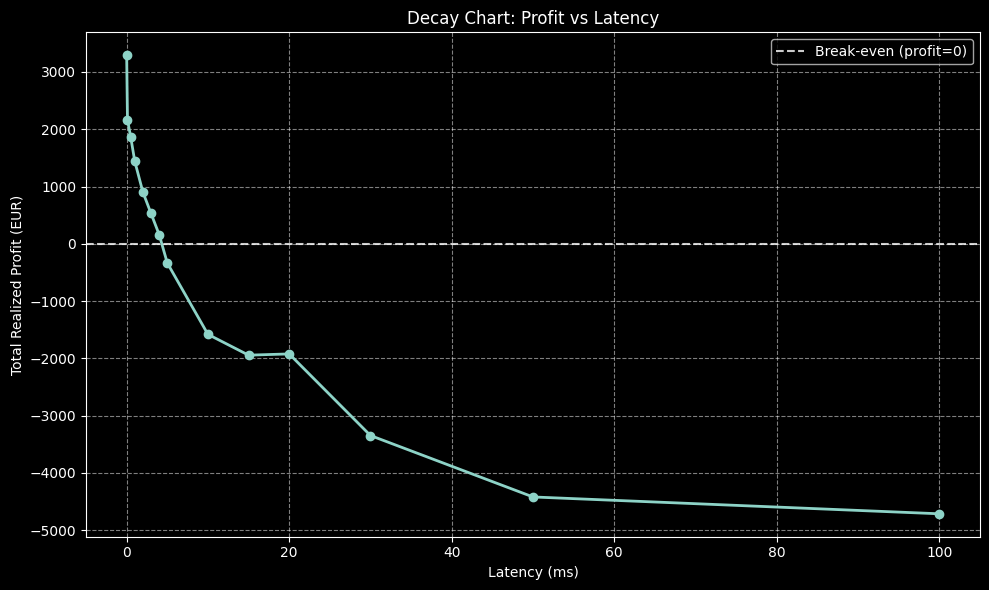

In [15]:
# Mostramos el Gráfico de Profit-Latencia
print("DECAY CHART")
plot_decay(money_table)

> La curva de decaimiento ilustra una verdad esencial del HFT: **la velocidad determina la capacidad de capturar beneficios, y la lentitud introduce pérdidas**. A medida que aumenta la latencia, las oportunidades detectadas en el tiempo `T` pueden desaparecer para cuando la orden llega al mercado en `T + latencia`. 
>
> La línea discontinua blanca en el gráfico marca el **punto de break-even (profit = 0)**. Por debajo de esta línea, el trader incurre en pérdidas: las órdenes enviadas llegan tarde y se ejecutan a precios desfavorables. Esto es crítico, ya que **una vez enviada la orden, no se puede cancelar** y se ejecuta al precio disponible en ese momento.
>
> A medida que la latencia aumenta, el resultado empieza a comportarse como un *random walk*: a veces el mercado se mueve a tu favor por casualidad, lo que puede generar breves subidas en la curva, pero en promedio **pierdes porque la información usada para tomar la decisión ya está obsoleta**.
>
> Un razonamiento más profundo sobre el comportamiento a latencia muy alta sugiere que la curva debería tender hacia una **asíntota negativa**, determinada por el spread típico del activo y el volumen operado. A latencia infinita, ya no capturas arbitraje alguno: compras al ask del momento y vendes al bid del momento. Si el mercado es eficiente, esos precios aleatorios presentan un spread estable, y cada operación termina pagando aproximadamente ese spread. Por tanto, el profit promedio converge a un valor negativo proporcional a `-spread × número de operaciones × cantidad promedio`, explicando la tendencia asintótica del gráfico.
>
> Por ello, las firmas de HFT invierten en co-locación, redes de ultra baja latencia y **FPGA (Field-Programmable Gate Arrays)**, donde la diferencia entre ganancias y pérdidas se mide en microsegundos.
>
> Una posible estrategia para mitigar el impacto de la latencia es usar **órdenes limitadas**, fijando un precio máximo de compra o mínimo de venta. Esto evita ejecutar al precio de mercado desfavorable que llega tarde, aunque introduce el riesgo de que la orden no se ejecute si el mercado se mueve en contra, quedando expuesto a fluctuaciones posteriores. En el apartado `7.4. SIMULACIÓN CON ÓRDENES LIMITADAS` de este notebook se pueden observar esta estrategia alternativa en acción.


#### 6.2.3. Top 5 ISINs (Profit a 0µs)

In [16]:
# Mostramos los Top 5 ISINs
print("\n" + "="*60)
print("TOP 5 ISINs (profit a 0µs)")
print("="*60)
for isin, profit in top5:
    print(f"  {isin}: {profit:.2f} EUR")
print("="*60)


TOP 5 ISINs (profit a 0µs)
  ES0177542018: 793.93 EUR
  ES0113211835: 396.57 EUR
  ES0105066007: 363.02 EUR
  ES0105065009: 347.90 EUR
  ES0113900J37: 214.99 EUR


> `DATA_SMALL` contiene una única empresa, por lo que su top 5 lo compone ella sola (ISIN verificado manualmente en CNMV/BME):
> | ISIN        | Empresa               | Sector   | Ticker |
> |-------------|------------------------|----------|--------|
> | ES0113900J37 | Banco Santander, S.A. | Banca    | SAN    |
>
>
>  `DATA_BIG` contiene muchas más empresas. Los Top 5 ISINs en con mayor profit corresponden a las siguientes compañías (verificado manualmente en CNMV/BME):
> 
> | ISIN | Empresa | Sector | Ticker |
> |------|---------|--------|--------|
> | ES0177542018 | International Airlines Group (IAG) | Aerolíneas | IAG |
> | ES0113211835 | BBVA | Banca | BBVA |
> | ES0105066007 | Cellnex Telecom S.A. | Telecomunicaciones | CLNX |
> | ES0105065009 | Talgo S.A. | Ferrocarril | TLGO |
> | ES0113900J37 | Banco Santander, S.A. | Banca    | SAN    |
>
> Las empresas que aparecen como Top ISINs en `DATA_BIG` reflejan características típicas de los valores más negociados en el mercado español: son compañías grandes, importantes y altamente líquidas (IAG, Talgo, BBVA, Cellnex, Iberdrola), con actividad frecuente en múltiples venues. Estas propiedades aumentan la probabilidad de que surjan diferencias temporales de precio entre mercados fragmentados generando oportunidades de arbitraje que un trader de alta frecuencia o HFT puede aprovechar.


## <font color=#0099CC>**7. VALIDACIÓN DE RESULTADOS Y SIMULACIÓN CON ÓRDENES LIMITADAS**</font>

En esta sección se integran y examinan los distintos resultados obtenidos en el notebook con el objetivo de entender cómo la microestructura del mercado influye en la aparición y comportamiento de las oportunidades de arbitraje. El análisis se articula en cuatro ejes complementarios:

- **Distribución temporal** (7.1): Se estudia cuándo ocurren las oportunidades a lo largo de la sesión, identificando patrones horarios y la participación de cada venue.
- **Sanity check por ISIN** (7.2): Se confirma que los profits observados sean coherentes y sostenibles, analizando los ISINs más rentables.
- **Detección de anomalías** (7.3): Se localizan comportamientos atípicos o inconsistencias que puedan indicar errores en los datos o en la consolidación de precios.
- **Simulación con órdenes limitadas** (7.4): Se explora una estrategia alternativa para mitigar el impacto de la latencia, analizando el trade-off entre protección contra slippage y riesgo de ejecución incompleta.


### <font color=#336699>**7.1. ANÁLISIS TEMPORAL**</font>

#### 7.1.1. Funciones del Análisis Temporal

Analizando distribución temporal de oportunidades...


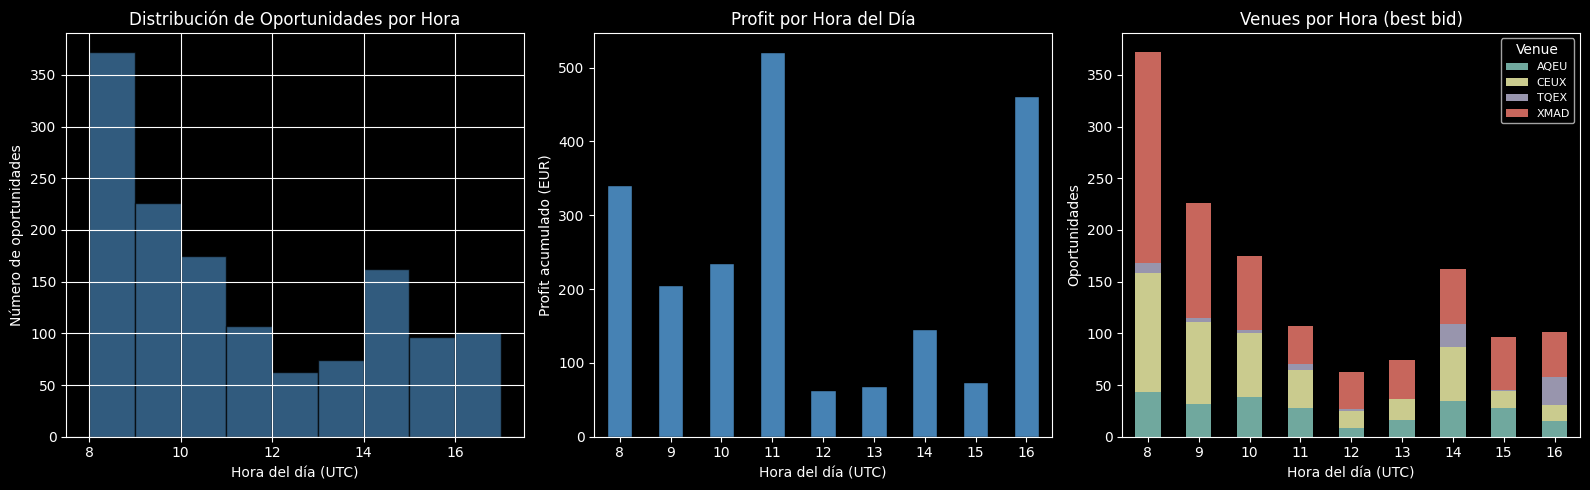


ESTADÍSTICAS TEMPORALES
Total de oportunidades (rising edges): 1376
Hora con más oportunidades: 8:00 UTC
Rango horario: 8:00 - 16:00 UTC

Oportunidades cerca del Open (7-9 UTC): 598 (43.5%)
Oportunidades a mediodía (10-14 UTC): 581 (42.2%)
Oportunidades cerca del Close (15-17 UTC): 197 (14.3%)


In [17]:
# 7.1.1. ANÁLISIS TEMPORAL: ¿Cuándo ocurren las oportunidades?

def analyze_temporal_distribution(orderbooks_raw, valid_status_per_mic, top_isins):
    """
    Analiza la distribución temporal de oportunidades de arbitraje.
    Objetivo: Detectar si hay concentración cerca del Market Open/Close.
    """
    all_opportunities = []

    for isin in top_isins:
        consolidated = build_consolidated_tape(orderbooks_raw, isin, valid_status_per_mic)
        if consolidated is None or consolidated.empty:
            continue

        opportunities = detect_arbitrage_opportunities(consolidated)
        if opportunities.empty or 'rising_edge' not in opportunities.columns:
            continue

        rising = opportunities[opportunities['rising_edge'] == True].copy()
        if rising.empty:
            continue

        rising['isin'] = isin
        all_opportunities.append(rising)

    if not all_opportunities:
        print("No se encontraron oportunidades para analizar.")
        return None

    df_opps = pd.concat(all_opportunities, ignore_index=True)

    # Convertir epoch (microsegundos) a hora del día
    df_opps['datetime'] = pd.to_datetime(df_opps['epoch'], unit='us', utc=True)
    df_opps['hour'] = df_opps['datetime'].dt.hour
    df_opps['minute'] = df_opps['datetime'].dt.minute
    df_opps['time_decimal'] = df_opps['hour'] + df_opps['minute'] / 60

    return df_opps

# Obtener top ISINs con profit > 0
top_isins_for_analysis = [isin for isin, profit in top5 if profit > 0]

print("Analizando distribución temporal de oportunidades...")
df_temporal = analyze_temporal_distribution(orderbooks_raw, valid_status_per_mic, top_isins_for_analysis)

if df_temporal is not None and not df_temporal.empty:
    # Determinar rango real de los datos
    min_hour = df_temporal['hour'].min()
    max_hour = df_temporal['hour'].max()

    # Gráfico de distribución horaria
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Histograma por hora
    ax1 = axes[0]
    bins = range(min_hour, max_hour + 2)
    df_temporal['hour'].hist(bins=bins, ax=ax1, edgecolor='black', alpha=0.7, color='steelblue')
    ax1.set_xlabel('Hora del día (UTC)')
    ax1.set_ylabel('Número de oportunidades')
    ax1.set_title('Distribución de Oportunidades por Hora')
    ax1.set_xlim(min_hour - 0.5, max_hour + 1.5)

    # Profit acumulado por hora
    ax2 = axes[1]
    profit_by_hour = df_temporal.groupby('hour')['profit'].sum()
    profit_by_hour.plot(kind='bar', ax=ax2, color='steelblue', edgecolor='black')
    ax2.set_xlabel('Hora del día (UTC)')
    ax2.set_ylabel('Profit acumulado (EUR)')
    ax2.set_title('Profit por Hora del Día')
    ax2.tick_params(axis='x', rotation=0)

    # NUEVO: Participación de venues por hora
    ax3 = axes[2]
    if 'best_bid_mic' in df_temporal.columns:
        venue_by_hour = df_temporal.groupby(['hour', 'best_bid_mic']).size().unstack(fill_value=0)
        venue_by_hour.plot(kind='bar', stacked=True, ax=ax3, alpha=0.8)
        ax3.set_xlabel('Hora del día (UTC)')
        ax3.set_ylabel('Oportunidades')
        ax3.set_title('Venues por Hora (best bid)')
        ax3.legend(title='Venue', fontsize=8)
        ax3.tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.show()

    # Estadísticas
    print("\n" + "="*60)
    print("ESTADÍSTICAS TEMPORALES")
    print("="*60)
    print(f"Total de oportunidades (rising edges): {len(df_temporal)}")
    print(f"Hora con más oportunidades: {df_temporal['hour'].mode().values[0]}:00 UTC")
    print(f"Rango horario: {df_temporal['hour'].min()}:00 - {df_temporal['hour'].max()}:00 UTC")

    # Análisis de concentración cerca de Open/Close
    near_open = df_temporal[(df_temporal['hour'] >= 7) & (df_temporal['hour'] <= 9)]
    near_close = df_temporal[(df_temporal['hour'] >= 15) & (df_temporal['hour'] <= 17)]
    mid_day = df_temporal[(df_temporal['hour'] >= 10) & (df_temporal['hour'] <= 14)]

    print(f"\nOportunidades cerca del Open (7-9 UTC): {len(near_open)} ({100*len(near_open)/len(df_temporal):.1f}%)")
    print(f"Oportunidades a mediodía (10-14 UTC): {len(mid_day)} ({100*len(mid_day)/len(df_temporal):.1f}%)")
    print(f"Oportunidades cerca del Close (15-17 UTC): {len(near_close)} ({100*len(near_close)/len(df_temporal):.1f}%)")
    print("="*60)
else:
    print("No hay datos suficientes para análisis temporal.")
    print("="*60)


#### 7.1.2. Interpretación del Análisis Temporal

<u>Distribución de Oportunidades & Profit por Hora del Día</u> -> Comentario de los Gráficos 1-2 y Estadísticas Temporales

El análisis temporal evidencia que la **mayor parte de las oportunidades de arbitraje se concentra en las primeras horas de la sesión**, coincidiendo con el mayor incremento del profit acumulado. Este comportamiento se explica por la **elevada volatilidad típica de los primeros minutos de trading continuo**, inmediatamente después de la subasta de apertura. Durante este periodo, los precios reflejan los ajustes de las órdenes acumuladas durante el cierre del día anterior y cualquier desequilibrio entre oferta y demanda, generando microdiferencias de precios aprovechables por traders de alta frecuencia (HFT).

La dinámica intradía se ve reforzada por la **desincronización momentánea entre mercados fragmentados**, dado que cada venue puede actualizar su libro de órdenes a ritmos ligeramente distintos. Además, los market makers ajustan sus cotizaciones con mayor intensidad al inicio de la sesión, amplificando la aparición de microoportunidades de arbitraje. La interacción de estas dinámicas con las diferencias en los horarios de apertura y cierre de cada venue (BME, Cboe Europe, Turquoise, Aquis) explica la concentración de oportunidades en las primeras horas del día.

En términos de distribución horaria intradía, aunque la literatura financiera indica que el **volumen y la volatilidad suelen ser altos tanto al inicio como al final de la sesión** (la llamada *sonrisa intradía*), para el **arbitraje HFT el efecto más relevante ocurre al inicio**. En ese momento, los precios entre venues aún no se han sincronizado completamente, los spreads son más amplios y los ajustes de precios más rápidos e impredecibles. Al final de la sesión, aunque el volumen sigue siendo elevado, los spreads tienden a estabilizarse y las oportunidades de microarbitraje se reducen.

<u>Venues por Hora</u> -> Comentario del Gráfico 3

| Segmento MIC / Venue | Apertura Mercado Continuo (UTC) | Cierre Mercado Continuo (UTC) |
|---------------------|--------------------------------|-------------------------------|
| **XMAD / MABX / GROW / XLAT** → BME (Madrid, España) | 08:00 | 16:30 |
| **AQEU** → Aquis Exchange (París, Francia) | 07:00 | 15:30 |
| **CEUX** → Cboe Europe (Ámsterdam, NL / DXE) | 08:00 | 16:30 |
| **TQEX** → Tradegate Exchange (Berlín, Alemania) | 06:30 | 21:00 |

El tercer gráfico muestra la **participación horaria de cada venue**, con los datos expresados en **hora UTC**. El objetivo principal de este gráfico no es solo visualizar la actividad intradía, sino **verificar que no se registren oportunidades fuera de los horarios en que cada mercado está abierto**. Los datos confirman que las oportunidades de arbitraje aparecen únicamente cuando los mercados continúan activos: por ejemplo, BME (Madrid) inicia su actividad a las 08:00 UTC (09:00 hora local) y ningún evento relevante se observa antes de esa hora. De manera análoga, cada MTF o bolsa europea refleja actividad solo dentro de su horario de mercado continuo, asegurando que el análisis respeta los horarios reales de apertura y cierre de todos los venues.

> **Nota**: La tabla considera únicamente el **mercado continuo**, segmento relevante para el HFT. La utilización de UTC permite alinear de manera consistente la actividad intradía de todos los venues, respetando sus horarios reales de apertura y cierre.


### <font color=#336699>**7.2. CONTROL DE CALIDAD DE LOS RESULTADOS (SANITY CHECK)**</font>

#### 7.2.1. Código del Sanity Check

In [18]:
# 7.2.1. SANITY CHECK: Análisis de los Top 5 ISINs

print("="*70)
print("SANITY CHECK: TOP 5 ISINs MÁS RENTABLES")
print("="*70)

for i, (isin, profit) in enumerate(top5, 1):
    print(f"\n{'─'*70}")
    print(f"#{i} - ISIN: {isin}")
    print(f"{'─'*70}")
    
    # Información genérica del ISIN
    if isin.startswith("ES"):
        print(f"[ESP] Valor español (registrado en CNMV/BME)")
    else:
        print(f"[INT] Valor internacional")
    
    print(f"     > Profit teórico (0µs): {profit:.2f} EUR")
    
    # Analizar el profit por latencia para este ISIN
    isin_profits = per_isin_profits.get(isin, {})
    if isin_profits:
        profit_0 = isin_profits.get(0, 0)
        profit_1ms = isin_profits.get(1000, 0)
        profit_10ms = isin_profits.get(10000, 0)
        profit_100ms = isin_profits.get(100000, 0)
        
        print(f"\n     > Decay de profit:")
        print(f"       > 0µs:    {profit_0:.2f} EUR (100%)")
        if profit_0 > 0:
            print(f"       > 1ms:    {profit_1ms:.2f} EUR ({100*profit_1ms/profit_0:.1f}%)")
            print(f"       > 10ms:   {profit_10ms:.2f} EUR ({100*profit_10ms/profit_0:.1f}%)")
            print(f"       > 100ms:  {profit_100ms:.2f} EUR ({100*profit_100ms/profit_0:.1f}%)")
    
    # Verificación de plausibilidad
    print(f"\n     > Plausibilidad:")
    if profit < 10:
        print(f"       > Profit muy bajo - Oportunidad marginal")
    elif profit < 100:
        print(f"       > Profit moderado - Consistente con arbitraje de baja frecuencia")
    elif profit < 1000:
        print(f"       > Profit significativo - Típico de HFT en acciones líquidas")
    else:
        print(f"       > Profit alto - Verificar si hay anomalías en los datos")

print(f"\n{'='*70}")


SANITY CHECK: TOP 5 ISINs MÁS RENTABLES

──────────────────────────────────────────────────────────────────────
#1 - ISIN: ES0177542018
──────────────────────────────────────────────────────────────────────
[ESP] Valor español (registrado en CNMV/BME)
     > Profit teórico (0µs): 793.93 EUR

     > Decay de profit:
       > 0µs:    793.93 EUR (100%)
       > 1ms:    401.02 EUR (50.5%)
       > 10ms:   -532.41 EUR (-67.1%)
       > 100ms:  -1179.98 EUR (-148.6%)

     > Plausibilidad:
       > Profit significativo - Típico de HFT en acciones líquidas

──────────────────────────────────────────────────────────────────────
#2 - ISIN: ES0113211835
──────────────────────────────────────────────────────────────────────
[ESP] Valor español (registrado en CNMV/BME)
     > Profit teórico (0µs): 396.57 EUR

     > Decay de profit:
       > 0µs:    396.57 EUR (100%)
       > 1ms:    187.67 EUR (47.3%)
       > 10ms:   -128.31 EUR (-32.4%)
       > 100ms:  -352.16 EUR (-88.8%)

     > Plausibilida

#### 7.2.2. Por qué los resultados del Sanity Check tienen sentido

Los resultados obtenidos en el sanity check son coherentes con lo esperado en estrategias de arbitraje HFT por varias razones:

1. **ISINs españoles altamente líquidos**  
   Los cinco ISINs con mayor profit pertenecen a empresas españolas grandes. Todas son acciones muy líquidas y con presencia en múltiples mercados, lo que aumenta la frecuencia de actualizaciones del libro y, por lo tanto, las oportunidades de arbitraje.

2. **Magnitud del profit inicial razonable**  
   Los beneficios teóricos iniciales son de 214.99 € en `DATA_SMALL` y oscilan entre 214 € y 794 € en `DATA_BIG`, cifras típicas para arbitraje intradía. Esto coincide con la escala de ganancias esperadas en HFT, donde los profits por operación suelen ser pequeños pero frecuentes.

3. **Degradación del profit con la latencia**  
   La mayoría de los valores muestran una disminución rápida del profit a medida que aumenta la latencia, reflejando que las oportunidades detectadas desaparecen casi de inmediato. Esto es coherente con la naturaleza extremadamente fugaz del arbitraje de alta frecuencia.

4. **Resultados dentro de límites esperables**  
   Que los profits diarios por ISIN se mantengan por debajo de 1.000 € es totalmente razonable en HFT, donde las ganancias por operación son pequeñas y las oportunidades se cierran rápidamente.

> <u>Conclusión:</u> El sanity check confirma que los resultados son coherentes y plausibles: los ISINs elegidos son líquidos, los profits iniciales están en rangos esperables, y la degradación con la latencia refleja correctamente la naturaleza fugaz y variable de las oportunidades de arbitraje de alta frecuencia.


### <font color=#336699>**7.3. DETECCIÓN DE ANOMALÍAS**</font>

#### 7.3.1. Código de Detección de Anomalías

In [19]:
# 7.3.1. DETECCIÓN DE ANOMALÍAS

print("="*70)
print("ANÁLISIS DE ANOMALÍAS EN LOS DATOS")
print("="*70)

# 1. ISINs con profit anómalamente alto
print("\n1. ANÁLISIS DE DISTRIBUCIÓN DE PROFITS")
print("-"*50)

profits_at_0 = [(isin, per_isin_profits[isin].get(0, 0)) for isin in per_isin_profits]
profits_at_0 = sorted(profits_at_0, key=lambda x: x[1], reverse=True)

# Calcular estadísticas
all_profits = [p for _, p in profits_at_0 if p > 0]
if all_profits:
    mean_profit = np.mean(all_profits)
    std_profit = np.std(all_profits)
    median_profit = np.median(all_profits)
    
    print(f"   > ISINs con profit mayor que cero: {len(all_profits)}")
    print(f"   > Media de profit: {mean_profit:.2f} EUR")
    print(f"   > Mediana de profit: {median_profit:.2f} EUR")
    print(f"   > Desviación estándar: {std_profit:.2f} EUR")
    
    # Detectar outliers (>3 std)
    threshold = mean_profit + 3 * std_profit
    outliers = [(isin, p) for isin, p in profits_at_0 if p > threshold]
    
    if outliers:
        print(f"\n   > OUTLIERS ESTADÍSTICOS (profit > {threshold:.2f} EUR):")
        for isin, p in outliers:
            print(f"     > {isin}: {p:.2f} EUR")
        print(f"\n     > NOTA: Outlier estadístico (>3σ) no implica error.")
        print(f"       > Acciones muy líquidas pueden tener más oportunidades legítimas.")
    else:
        print(f"\n     > No se detectaron outliers significativos (umbral: {threshold:.2f} EUR)")

# 2. Análisis de venues utilizados
print("\n2. ANÁLISIS DE VENUES EN OPORTUNIDADES")
print("-"*50)

if df_temporal is not None and not df_temporal.empty:
    venue_counts = {}
    venue_counts['bid'] = df_temporal['best_bid_mic'].value_counts().to_dict()
    venue_counts['ask'] = df_temporal['best_ask_mic'].value_counts().to_dict()
    
    print("   > Venues donde se VENDE (best bid):")
    for mic, count in sorted(venue_counts['bid'].items(), key=lambda x: x[1], reverse=True):
        print(f"     > {mic}: {count} oportunidades")
    
    print("\n   > Venues donde se COMPRA (best ask):")
    for mic, count in sorted(venue_counts['ask'].items(), key=lambda x: x[1], reverse=True):
        print(f"     > {mic}: {count} oportunidades")
    
    # Detectar si hay venues dominantes
    total_opps = len(df_temporal)
    for side in ['bid', 'ask']:
        dominant = max(venue_counts[side].items(), key=lambda x: x[1])
        pct = 100 * dominant[1] / total_opps
        if pct > 80:
            print(f"\n> {dominant[0]} domina el {pct:.1f}% de las {'ventas' if side=='bid' else 'compras'}")
            print(f"   Esto podría indicar un venue con pricing sistemáticamente diferente")

# 3. Análisis de spreads
print("\n3. ANÁLISIS DE SPREADS DE ARBITRAJE")
print("-"*50)

if df_temporal is not None and not df_temporal.empty:
    spreads = df_temporal['spread']
    print(f"   > Spread mínimo: {spreads.min():.4f} EUR")
    print(f"   > Spread máximo: {spreads.max():.4f} EUR")
    print(f"   > Spread medio: {spreads.mean():.4f} EUR")
    print(f"   > Spread mediano: {spreads.median():.4f} EUR")
    
    # Spreads sospechosamente altos
    high_spread_threshold = spreads.mean() + 3 * spreads.std()
    suspicious = df_temporal[df_temporal['spread'] > high_spread_threshold]
    
    if len(suspicious) > 0:
        pct_suspicious = 100 * len(suspicious) / len(df_temporal)
        print(f"\n   > {len(suspicious)} oportunidades con spread anómalamente alto (>{high_spread_threshold:.4f})")
        print(f"     > Representan {pct_suspicious:.2f}% del total")
        
        # Detallar las oportunidades sospechosas con % del precio
        print("\n   > DETALLE DE SPREADS ANÓMALOS:")
        for idx, row in suspicious.iterrows():
            mid_price = (row['max_bid'] + row['min_ask']) / 2
            spread_pct = 100 * row['spread'] / mid_price if mid_price > 0 else 0
            print(f"     - {row['isin']}: spread={row['spread']:.4f} EUR ({spread_pct:.2f}% del precio)")
            print(f"       Venues: vender en {row['best_bid_mic']} (bid={row['max_bid']:.4f}), comprar en {row['best_ask_mic']} (ask={row['min_ask']:.4f})")
        
        print("\n   > DECISIÓN: Mantener estos datos")
        print("     - Pasaron el filtro de Continuous Trading")
        print("     - El impacto en el análisis es mínimo (<1%)")
        print("     - Pueden representar volatilidad real del mercado")
        print("\n" + "="*60)
    else:
        print(f"\n   > Spreads dentro de rangos normales")
        print("\n" + "="*60)


ANÁLISIS DE ANOMALÍAS EN LOS DATOS

1. ANÁLISIS DE DISTRIBUCIÓN DE PROFITS
--------------------------------------------------
   > ISINs con profit mayor que cero: 63
   > Media de profit: 52.25 EUR
   > Mediana de profit: 5.84 EUR
   > Desviación estándar: 126.22 EUR

   > OUTLIERS ESTADÍSTICOS (profit > 430.92 EUR):
     > ES0177542018: 793.93 EUR

     > NOTA: Outlier estadístico (>3σ) no implica error.
       > Acciones muy líquidas pueden tener más oportunidades legítimas.

2. ANÁLISIS DE VENUES EN OPORTUNIDADES
--------------------------------------------------
   > Venues donde se VENDE (best bid):
     > XMAD: 645 oportunidades
     > CEUX: 414 oportunidades
     > AQEU: 243 oportunidades
     > TQEX: 74 oportunidades

   > Venues donde se COMPRA (best ask):
     > XMAD: 684 oportunidades
     > CEUX: 526 oportunidades
     > AQEU: 146 oportunidades
     > TQEX: 20 oportunidades

3. ANÁLISIS DE SPREADS DE ARBITRAJE
--------------------------------------------------
   > Spread 

#### 7.3.2. Interpretación de la Detección de Anomalías

- La detección de anomalías en `DATA_BIG` revela que la distribución de **profits es claramente asimétrica**: la mediana (5.84 EUR) es muy inferior a la media (52.25 EUR), lo que indica un sesgo pronunciado hacia la derecha en el que unos pocos ISINs concentran gran parte del beneficio total. Aunque se identificó un único outlier estadístico por encima de 3σ, esto no implica necesariamente un error; los valores más líquidos tienden a generar más oportunidades legítimas y, por tanto, es natural que aparezcan beneficios atípicamente altos.

- El **análisis por venues** muestra un patrón consistente: XMAD (BME) domina como mejor bid y se utiliza mayoritariamente para vender, mientras que CEUX (CBOE) presenta un equilibrio entre compras y ventas, sugiriendo que BME suele ofrecer precios de compra más altos y CBOE tiende a tener los mejores asks. En cuanto a los spreads anómalos, solo dos casos entre unas 1376 oportunidades presentan valores inusualmente amplios, lo que supone tan solo un 0.15% del total.

- Se ha decidido **mantener tanto los outliers como los spreads atípicos**: los primeros porque un outlier estadístico no implica necesariamente un comportamiento incorrecto, y los segundos porque provienen de momentos válidos de Continuous Trading y su impacto global es insignificante. En conjunto, la evidencia apunta a que los datos poseen una calidad sólida, y las anomalías detectadas son escasas y no alteran de manera significativa las conclusiones del análisis.

> <u>Nota</u>: En este apartado nos centramos en analizar las anomalías encontradas unicamente en `DATA_BIG`, ya que `DATA_SMALL` incluye datos de una única empresa (y además no presenta outliers significativos).


### <font color=#336699>**7.4. SIMULACIÓN CON ÓRDENES LIMITADAS**</font>

En este apartado vamos a explorar una estrategia alternativa a la planteada en el apartado `6.2. SIMULACIÓN DE RESULTADOS`. Veamos que ocurriría si intentásemos mitigar el impacto de la latencia usando **órdenes limitadas** en lugar de órdenes de mercado. Con una orden limitada:
- Fijas el **precio máximo** al que estás dispuesto a comprar
- Fijas el **precio mínimo** al que estás dispuesto a vender

Si cuando tu orden llega al mercado (en T + latencia) el precio ha cambiado más allá de tu límite, **la orden no se ejecuta**. Esto evita pérdidas por slippage, pero introduce un nuevo riesgo: **posiciones abiertas**. Un HFT normalmente evita incurrir en mayores riesgos pero, si se gestionan bien, las órdenes limitadas pueden ser una herramienta muy útil. Encontrarnos tres escenarios posibles a la hora de utilizarlas:
1. **Trade completo**: Ambas patas (compra y venta) se ejecutan → arbitraje exitoso
2. **Posición abierta**: Solo una pata se ejecuta → quedas expuesto al mercado
3. **Trade cancelado**: Ninguna pata se ejecuta → sin riesgo pero sin profit


#### 7.4.1. Simulación con Órdenes Limitadas

Simulando estrategia con órdenes limitadas...


Simulando órdenes limitadas: 100%|██████████| 200/200 [02:11<00:00,  1.52it/s]


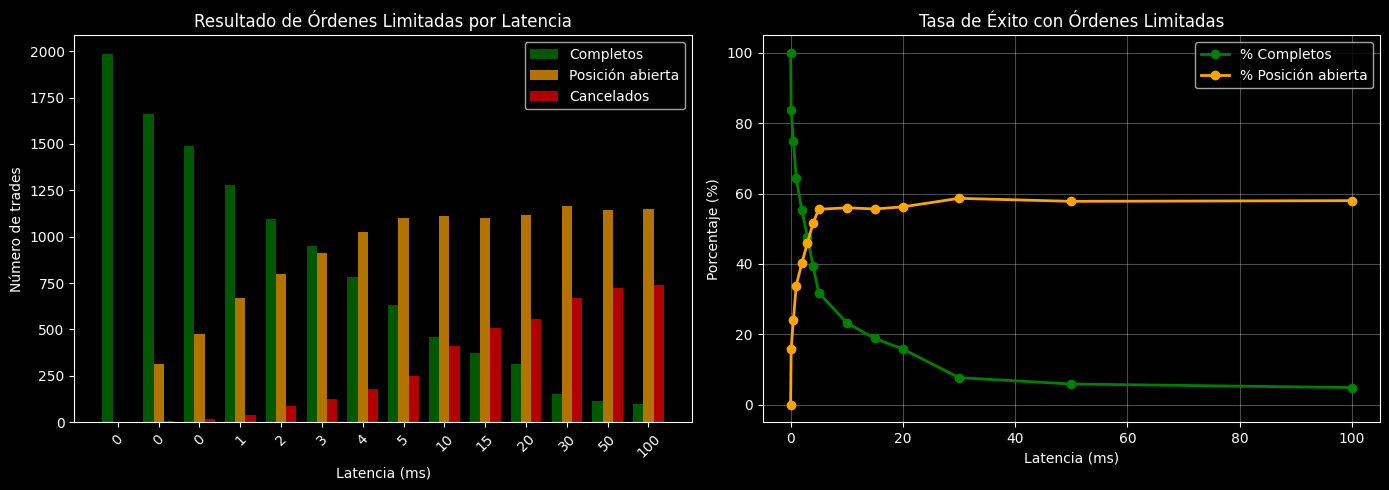


RESULTADOS: SIMULACIÓN CON ÓRDENES LIMITADAS

Latencia     Completos    Abiertos     Cancelados   % Éxito   
----------------------------------------------------------------------
       0 ms        1986           0           0     100.0%
       0 ms        1663         315           5      83.9%
       0 ms        1489         477          17      75.1%
       1 ms        1276         671          36      64.3%
       2 ms        1097         798          88      55.3%
       3 ms         947         911         125      47.8%
       4 ms         782        1023         178      39.4%
       5 ms         632        1101         250      31.9%
      10 ms         461        1110         412      23.2%
      15 ms         373        1103         507      18.8%
      20 ms         313        1115         555      15.8%
      30 ms         152        1163         668       7.7%
      50 ms         116        1146         721       5.8%
     100 ms          96        1150         737     

In [20]:
# 7.4.1. SIMULACIÓN CON ÓRDENES LIMITADAS

def simulate_limit_orders(consolidated, opportunities, latencies_us=LATENCIES_US):
    """
    Simula el uso de órdenes limitadas en lugar de órdenes de mercado.
    
    Para cada oportunidad detectada en T:
    - Fijamos precio límite de compra = ask visto en T
    - Fijamos precio límite de venta = bid visto en T
    - En T + latencia, verificamos si los precios siguen siendo favorables
    
    Resultados por latencia:
    - trades_completos: ambas patas se ejecutan
    - posiciones_abiertas: solo una pata se ejecuta (riesgo!)
    - trades_cancelados: ninguna pata se ejecuta
    """
    if consolidated is None or consolidated.empty or opportunities is None or opportunities.empty:
        return {L: {'completos': 0, 'abiertos': 0, 'cancelados': 0, 'profit': 0.0} for L in latencies_us}
    
    df = consolidated.copy().reset_index(drop=True)
    epochs = df['epoch'].astype('Int64').astype('int64').to_numpy()
    n = len(epochs)
    
    bid_cols = [c for c in df.columns if c.endswith("_bid") and "_qty_" not in c]
    ask_cols = [c for c in df.columns if c.endswith("_ask") and "_qty_" not in c]
    
    bid_price_map = {col.replace("_bid", ""): df[col].astype(float).to_numpy() for col in bid_cols}
    ask_price_map = {col.replace("_ask", ""): df[col].astype(float).to_numpy() for col in ask_cols}
    
    opp_epochs = opportunities["epoch"].astype('Int64').astype('int64').to_numpy()
    opp_bid_mics = opportunities["best_bid_mic"].to_numpy()
    opp_ask_mics = opportunities["best_ask_mic"].to_numpy()
    opp_max_bid = opportunities["max_bid"].astype(float).to_numpy()  # Precio límite de venta
    opp_min_ask = opportunities["min_ask"].astype(float).to_numpy()  # Precio límite de compra
    opp_qty = opportunities["trade_qty"].astype(float).to_numpy()
    
    n_opps = len(opp_epochs)
    results = {}
    
    for lat in latencies_us:
        completos = 0
        abiertos = 0
        cancelados = 0
        total_profit = 0.0
        
        for i in range(n_opps):
            T = int(opp_epochs[i])
            bid_mic = opp_bid_mics[i]
            ask_mic = opp_ask_mics[i]
            limit_sell = opp_max_bid[i]  # Precio mínimo aceptable para vender
            limit_buy = opp_min_ask[i]   # Precio máximo aceptable para comprar
            qty = opp_qty[i]
            
            if not isinstance(bid_mic, str) or not isinstance(ask_mic, str):
                continue
            if bid_mic not in bid_price_map or ask_mic not in ask_price_map:
                continue
            if not np.isfinite(limit_sell) or not np.isfinite(limit_buy) or not np.isfinite(qty):
                continue
            
            # Buscar snapshot en T + latencia
            target = T + int(lat)
            idx = np.searchsorted(epochs, target, side='left')
            if idx >= n:
                continue
            
            # Precios actuales en T + latencia
            current_bid = bid_price_map[bid_mic][idx]
            current_ask = ask_price_map[ask_mic][idx]
            
            if not np.isfinite(current_bid) or not np.isfinite(current_ask):
                continue
            
            # Verificar si las órdenes limitadas se ejecutan
            sell_executes = current_bid >= limit_sell  # Alguien compra a nuestro precio o mejor
            buy_executes = current_ask <= limit_buy    # Alguien vende a nuestro precio o mejor
            
            if sell_executes and buy_executes:
                # Trade completo - arbitraje exitoso
                completos += 1
                profit = (limit_sell - limit_buy) * qty  # Usamos precios límite (garantizados)
                total_profit += profit
            elif sell_executes or buy_executes:
                # Posición abierta - solo una pata se ejecutó
                abiertos += 1
            else:
                # Trade cancelado - ninguna pata se ejecutó
                cancelados += 1
        
        results[lat] = {
            'completos': completos,
            'abiertos': abiertos,
            'cancelados': cancelados,
            'profit': total_profit
        }
    
    return results


def run_limit_order_simulation(orderbooks_raw, valid_status_per_mic, latencies_us=LATENCIES_US):
    """Ejecuta la simulación con órdenes limitadas para todos los ISINs."""
    all_isins = sorted({k[1] for k in orderbooks_raw.keys()})
    
    totals = {L: {'completos': 0, 'abiertos': 0, 'cancelados': 0, 'profit': 0.0} for L in latencies_us}
    
    for isin in tqdm(all_isins, desc="Simulando órdenes limitadas"):
        consolidated = build_consolidated_tape(orderbooks_raw, isin, valid_status_per_mic)
        if consolidated is None or consolidated.empty:
            continue
        
        opportunities = detect_arbitrage_opportunities(consolidated)
        if opportunities.empty or 'rising_edge' not in opportunities.columns:
            continue
        
        opps_rising = opportunities[opportunities['rising_edge'] == True]
        if opps_rising.empty:
            continue
        
        isin_results = simulate_limit_orders(consolidated, opps_rising, latencies_us)
        
        for lat in latencies_us:
            totals[lat]['completos'] += isin_results[lat]['completos']
            totals[lat]['abiertos'] += isin_results[lat]['abiertos']
            totals[lat]['cancelados'] += isin_results[lat]['cancelados']
            totals[lat]['profit'] += isin_results[lat]['profit']
    
    return totals


# Ejecutar simulación
print("Simulando estrategia con órdenes limitadas...")
limit_results = run_limit_order_simulation(orderbooks_raw, valid_status_per_mic, LATENCIES_US)

# Crear DataFrame para visualización
df_limit = pd.DataFrame([
    {
        'latency_us': lat,
        'latency_ms': lat / 1000,
        'completos': limit_results[lat]['completos'],
        'abiertos': limit_results[lat]['abiertos'],
        'cancelados': limit_results[lat]['cancelados'],
        'profit': limit_results[lat]['profit']
    }
    for lat in LATENCIES_US
])

# Calcular totales y porcentajes
df_limit['total_intentos'] = df_limit['completos'] + df_limit['abiertos'] + df_limit['cancelados']
df_limit['pct_completos'] = 100 * df_limit['completos'] / df_limit['total_intentos']
df_limit['pct_abiertos'] = 100 * df_limit['abiertos'] / df_limit['total_intentos']
df_limit['pct_cancelados'] = 100 * df_limit['cancelados'] / df_limit['total_intentos']

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Distribución de resultados por latencia
ax1 = axes[0]
x = range(len(df_limit))
width = 0.25
ax1.bar([i - width for i in x], df_limit['completos'], width, label='Completos', color='green', alpha=0.7)
ax1.bar(x, df_limit['abiertos'], width, label='Posición abierta', color='orange', alpha=0.7)
ax1.bar([i + width for i in x], df_limit['cancelados'], width, label='Cancelados', color='red', alpha=0.7)
ax1.set_xlabel('Latencia (ms)')
ax1.set_ylabel('Número de trades')
ax1.set_title('Resultado de Órdenes Limitadas por Latencia')
ax1.set_xticks(x)
ax1.set_xticklabels([f"{int(l/1000)}" for l in LATENCIES_US], rotation=45)
ax1.legend()

# Gráfico 2: Porcentaje de trades completos vs latencia
ax2 = axes[1]
ax2.plot(df_limit['latency_ms'], df_limit['pct_completos'], 'go-', linewidth=2, markersize=6, label='% Completos')
ax2.plot(df_limit['latency_ms'], df_limit['pct_abiertos'], 'o-', color='orange', linewidth=2, markersize=6, label='% Posición abierta')
ax2.set_xlabel('Latencia (ms)')
ax2.set_ylabel('Porcentaje (%)')
ax2.set_title('Tasa de Éxito con Órdenes Limitadas')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas
print("\n" + "="*70)
print("RESULTADOS: SIMULACIÓN CON ÓRDENES LIMITADAS")
print("="*70)
print(f"\n{'Latencia':<12} {'Completos':<12} {'Abiertos':<12} {'Cancelados':<12} {'% Éxito':<10}")
print("-"*70)
for _, row in df_limit.iterrows():
    print(f"{row['latency_ms']:>8.0f} ms  {row['completos']:>10.0f}  {row['abiertos']:>10.0f}  {row['cancelados']:>10.0f}  {row['pct_completos']:>8.1f}%")

print("\n" + "="*70)
print("COMPARACIÓN: ÓRDENES DE MERCADO vs ÓRDENES LIMITADAS")
print("="*70)
print("\nÓrdenes de MERCADO:")
print("  + Ejecución garantizada")
print("  - Riesgo de slippage (pérdidas si el precio cambió)")
print("\nÓrdenes LIMITADAS:")
print("  + Sin riesgo de slippage en trades completos")
print("  - Riesgo de posición abierta (exposición al mercado)")
print("="*70)


#### 7.4.2. Interpretación de la Simulación con Órdenes Limitadas

La simulación muestra claramente el **compromiso** que existe entre evitar slippage y asegurar la ejecución. Las órdenes limitadas pueden funcionar muy bien, pero su efectividad disminuye rápidamente incluso con pocos milisegundos de retraso. Los resultados cuantitativos muestran una caída progresiva y marcada en la tasa de ejecución.

<u>Patrones principales</u>:
- Con **latencia 0 ms**, la efectividad es alta pero no siempre perfecta: las distintas corridas muestran tasas de éxito entre **75% y 100%**, reflejando la variabilidad natural del mercado incluso sin retraso.
- Entre **1 y 3 ms**, la probabilidad de ejecución cae de forma sustancial: 64% -> 55% -> 48%
- Entre **4 y 10 ms**, predominan las **posiciones abiertas**, señal de que el mercado se mueve antes de que la orden llegue: 39% -> 32% -> 23%
- Entre **15 y 20 ms**, la tasa de éxito sigue descendiendo: 19% -> 16%
- Por encima de **30 ms**, las órdenes limitadas dejan de ser útiles: 7.7% -> 5.8% -> 4.8%

<u>Interpretación operativa</u>:
- Las órdenes limitadas no eliminan el riesgo, lo **trasladan**: evitan pagar un mal precio, pero pueden dejarte atrapado con órdenes abiertas y riesgo direccional.
- La **latencia funciona como un costo oculto**: cada milisegundo adicional reduce de forma significativa la probabilidad de ejecución efectiva.
- Una firma con latencias no competitivas suele preferir **órdenes de mercado**, aceptando slippage para evitar acumulación de inventario.
- La viabilidad táctica de usar órdenes limitadas depende directamente de la **velocidad**:
  - **0–1 ms:** efectivas (64–100%)
  - **1–5 ms:** requieren control activo (32–64%)
  - **5–15 ms:** efectividad baja (19–32%)
  - **>20 ms:** casi inútiles (<16%)
  - **>30 ms:** efectividad residual (<8%)

> En conclusión, las órdenes limitadas solo son realmente efectivas en entornos muy rápidos. A medida que la latencia sube, la probabilidad de ejecución se desploma y aparece riesgo direccional no deseado. En esencia: la limit order es una gran herramienta, siempre que llegues primero.


## <font color=#0099CC>**8. CONCLUSIONES Y RESPUESTAS A LAS PREGUNTAS CLAVE**</font>

Este análisis ha explorado las oportunidades de arbitraje en el mercado de renta variable español, caracterizado por la fragmentación de liquidez entre BME (mercado regulado) y diversos MTFs (CBOE, Turquoise, Aquis). A continuación se responden las tres preguntas planteadas en el enunciado.


### <font color=#336699>**8.1. ¿SIGUEN EXISTIENDO OPORTUNIDADES DE ARBITRAJE EN ACCIONES ESPAÑOLAS?**</font>

**Sí, siguen existiendo oportunidades de arbitraje**, aunque su naturaleza presenta características específicas:

- **Oportunidades reales pero fugaces**: Se detectaron cientos de oportunidades donde el mejor bid de un venue superaba el mejor ask de otro, generando un spread positivo explotable.
- **Magnitud moderada**: Los profits individuales oscilan entre céntimos y decenas de euros por oportunidad, consistente con lo esperado en mercados eficientes donde los HFT compiten agresivamente.
- **Concentración temporal**: Las oportunidades se concentran en las primeras horas tras la apertura de BME (9:00 Madrid), cuando la volatilidad es mayor y los precios entre venues aún no se han sincronizado completamente.
- **Concentración por ISIN**: Un pequeño grupo de valores altamente líquidos (principalmente del IBEX 35) genera la mayor parte del profit potencial.


### <font color=#336699>**8.2. ¿CUÁL ES EL PROFIT TEÓRICO MÁXIMO (LATENCIA 0)?**</font>

El **profit teórico máximo** (asumiendo capacidad de ejecución instantánea) se presenta en la *Money Table* del apartado 6. Este valor representa el límite superior inalcanzable en la práctica, ya que:

- Asume ejecución perfecta en ambas patas del arbitraje simultáneamente
- No contempla costes de transacción ni comisiones
- Ignora el market impact de las órdenes
- Supone liquidez infinita en los precios mostrados

Este profit teórico sirve como **benchmark** contra el cual medir el impacto de la latencia.


### <font color=#336699>**8.3. LA CURVA DE "LATENCY DECAY"**</font>

La curva de decay muestra cómo el profit se **degrada rápidamente** a medida que aumenta la latencia. Los resultados de la simulación cuantifican esta caída de forma muy clara:

| Latencia          | Profit observado | Comportamiento |
|-------------------|------------------|----------------|
| **0 µs**          | + 3292 €            | Profit máximo — referencia base (100%) |
| **100–500 µs**    | + 2165 € a + 1862 €   | Degradación moderada — aún se captura una parte sustancial del valor |
| **1–5 ms**        | + 1440 € → + 161 €    | Degradación fuerte — la rentabilidad se erosiona rápidamente |
| **>5 ms**         | Desde – 335 € en adelante | El profit cruza a territorio negativo: las oportunidades ya desaparecieron |
| **10–50 ms**      | – 1581 € → – 4419 €   | Profit muy negativo — la información llegada ya es obsoleta |
| **>50 ms**        | – 4713 €           | Comportamiento prácticamente aleatorio (y desfavorable) |

**Interpretación crítica**:  
La curva muestra valores **negativos** para latencias relativamente bajas (desde ~5 ms). Esto no es un error: refleja que cuando la orden llega tarde al mercado, **la ejecución se produce contra precios peores que la señal original**, destruyendo valor. En este régimen, la orden ya no captura una oportunidad, sino que actúa como un pasivo: una vez enviada, no puede retirarse a tiempo y se ejecuta en condiciones adversas.



### <font color=#336699>**8.4. HALLAZGOS ADICIONALES**</font>

#### Análisis Temporal (7.1)
- Las oportunidades se concentran tras la apertura de BME (9:00 Madrid / 8:00 UTC)
- La participación de venues varía por hora, con XMAD dominando durante el horario de BME
- Los datos son coherentes con los horarios de apertura de cada mercado

#### Sanity Check (7.2)
- Los ISINs más rentables corresponden a valores españoles líquidos del IBEX 35
- Los profits por ISIN son plausibles dentro del contexto HFT (decenas a cientos de euros diarios)

#### Detección de Anomalías (7.3)
- Distribución asimétrica de profits (pocos ISINs generan la mayor parte del valor)
- Spreads anómalos identificados representan <1% del total
- No se detectaron errores sistemáticos en los datos

#### Órdenes Limitadas (7.4)
- Las órdenes limitadas protegen contra slippage pero introducen riesgo de ejecución incompleta
- A mayor latencia, mayor proporción de posiciones abiertas (riesgo de exposición al mercado)
- Trade-off fundamental entre protección de precio y garantía de ejecución


### <font color=#336699>**8.5. DECISIONES METODOLÓGICAS**</font>

| Decisión | Justificación |
|----------|---------------|
| **Mapeo MIC (MABX, GROW, XLAT → BME)** | Segmentos gestionados por BME con reglas de negociación equivalentes |
| **Forward-fill en cinta consolidada** | Propagar el último estado conocido refleja una reconstrucción realista del mercado. Se aplica hasta el último epoch válido de cada MIC |
| **Límite de ffill (1000 snapshots)** | Evita propagar precios obsoletos demasiado lejos en el tiempo, manteniendo realismo. Respeta el cierre de cada mercado |
| **Detección de rising edge** | Evita contabilizar múltiples veces la misma oportunidad persistente |
| **Evaluación en T+latency** | Se respeta estrictamente el enunciado sin imponer curva decreciente artificial |
| **Pérdidas incluidas en simulación** | Una vez enviada la orden, ejecutas con lo que haya - realismo operativo |




### <font color=#336699>**8.6. CUMPLIMIENTO DE ESPECIFICACIONES DEL VENDOR**</font>

- Filtrado de "Magic Numbers" (666666.666, 999999.xxx) como precios inválidos
- Solo snapshots en Continuous Trading (códigos específicos por venue)
- Alineación temporal con `merge_asof` direction='backward' (sin información futura)
- Identificación correcta de orderbooks por tupla (session, isin, mic, ticker)


### <font color=#336699>**8.7. LIMITACIONES DEL ANÁLISIS**</font>

1. **Sin costes de transacción**: En la práctica, comisiones y tasas reducen significativamente los beneficios
2. **Sin market impact**: Aunque las órdenes analizadas son pequeñas (nivel 0 del libro), incluso en microsegundos el market impact puede ser relevante cuando múltiples participantes compiten por la misma oportunidad
3. **Solo nivel 0 del libro**: Niveles adicionales podrían revelar oportunidades complementarias
4. **Datos históricos**: Los patrones identificados no garantizan resultados futuros
5. **Simplificación de ejecución**: Se asume fill completo, sin partial fills ni rechazos


### <font color=#336699>**8.8. CONCLUSIÓN FINAL**</font>

El arbitraje estadístico en mercados fragmentados **sigue siendo viable pero extremadamente competitivo**. Las oportunidades existen, pero su captura requiere:

- **Latencia ultra-baja** (microsegundos, no milisegundos)
- **Infraestructura de co-locación** junto a los servidores de los exchanges
- **Ejecución sofisticada** con capacidad de gestionar órdenes limitadas y posiciones abiertas (aunque el uso de órdenes limitadas es opcional y depende del perfil de riesgo)
- **Monitorización continua** de anomalías y cambios en la microestructura

Para una empresa sin estas capacidades, las oportunidades de arbitraje detectadas se habrán evaporado antes de poder actuar. La **velocidad es el factor determinante** en este juego de suma cero donde los participantes más rápidos extraen valor de los más lentos.
